In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/AAPL.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [26]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

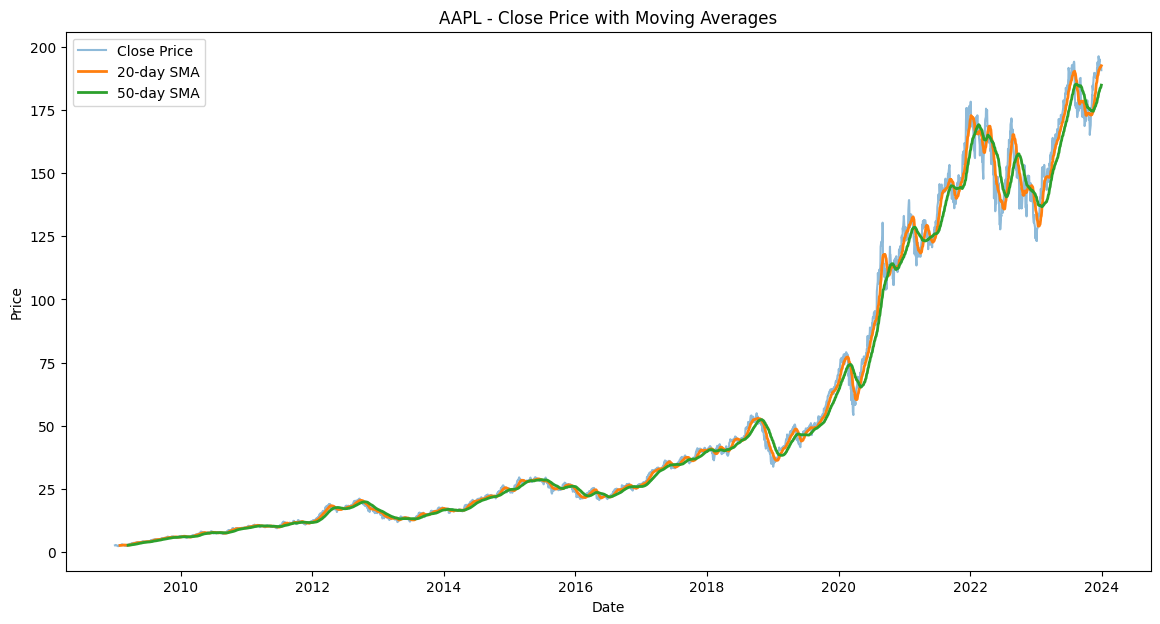

In [27]:
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], label='Close Price', alpha=0.5)
plt.plot(df['Date'], df['SMA_20'], label='20-day SMA', linewidth=2)
plt.plot(df['Date'], df['SMA_50'], label='50-day SMA', linewidth=2)
plt.title('AAPL - Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [28]:
# RSI calculation
window = 14
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()

rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

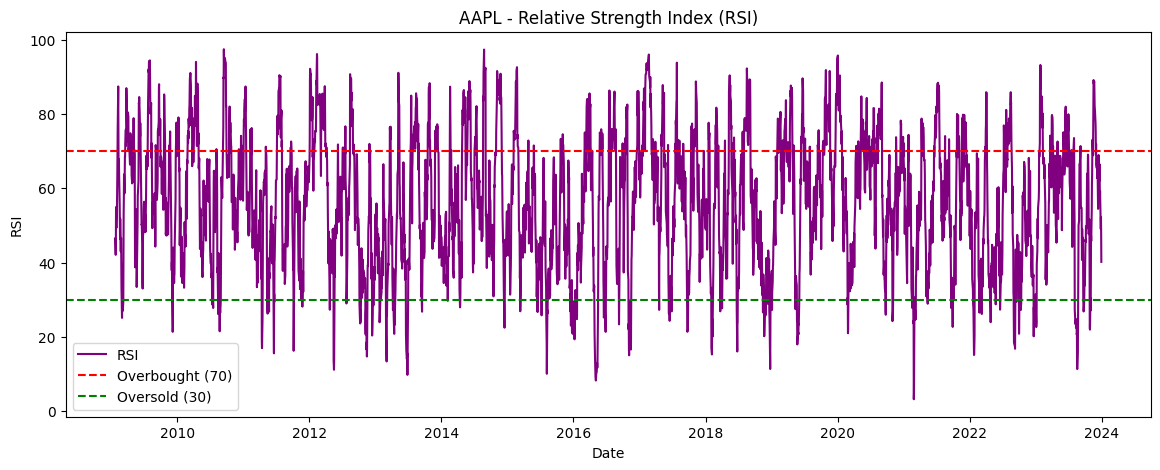

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['RSI'], label='RSI', color='purple')
plt.axhline(y=70, color='r', linestyle='--', label='Overbought (70)')
plt.axhline(y=30, color='g', linestyle='--', label='Oversold (30)')
plt.title('AAPL - Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

In [30]:
# Calculate EMAs
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

print("EMA_12 (12-day):", df['EMA_12'].iloc[-1])
print("EMA_26 (26-day):", df['EMA_26'].iloc[-1])

EMA_12 (12-day): 192.10078654372063
EMA_26 (26-day): 190.54124770548876


In [31]:
# Calculate MACD
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['Histogram'] = df['MACD'] - df['Signal']

print(f"Latest MACD: {df['MACD'].iloc[-1]:.4f}")
print(f"Latest Signal: {df['Signal'].iloc[-1]:.4f}")
print(f"Latest Histogram: {df['Histogram'].iloc[-1]:.4f}")

Latest MACD: 1.5595
Latest Signal: 2.4246
Latest Histogram: -0.8651


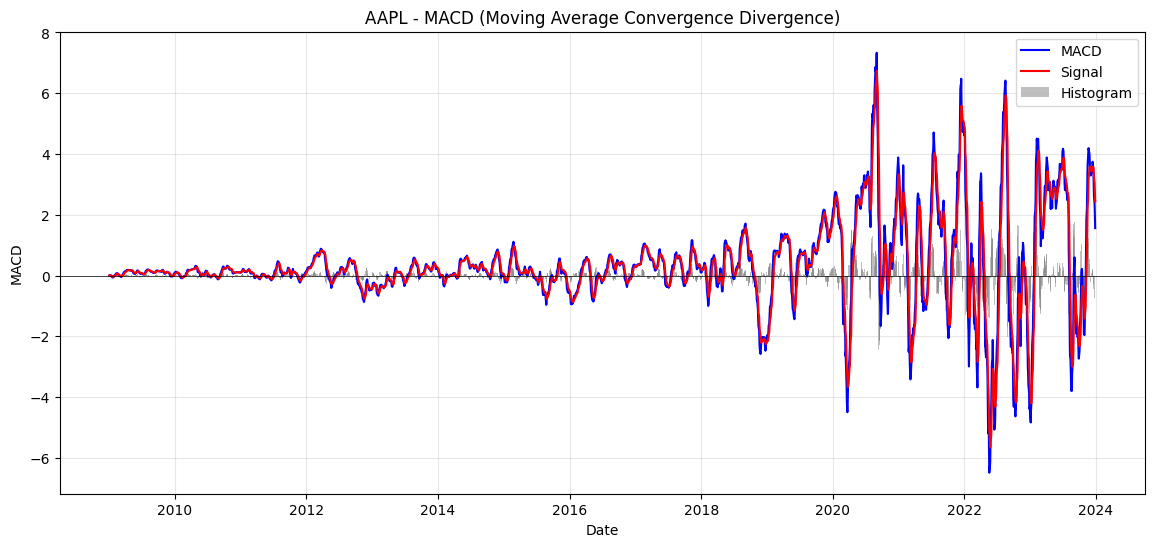

In [32]:
# MACD Plot
plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['MACD'], label='MACD', color='blue', linewidth=1.5)
plt.plot(df['Date'], df['Signal'], label='Signal', color='red', linewidth=1.5)
plt.bar(df['Date'], df['Histogram'], label='Histogram', color='gray', alpha=0.5, width=3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.title('AAPL - MACD (Moving Average Convergence Divergence)')
plt.xlabel('Date')
plt.ylabel('MACD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
print("=== Data Preparation Summary ===")
print(f"Data source: AAPL.csv")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total rows: {len(df)}")
print(f"\nMissing values check:")
print(f"  Close: {df['Close'].isna().sum()} missing")
print(f"  Volume: {df['Volume'].isna().sum()} missing")
print(f"\nData types:")
print(df[['Date', 'Close', 'Volume']].dtypes)
print("\n✅ No missing values found. Data is clean and ready for analysis.")

=== Data Preparation Summary ===
Data source: AAPL.csv
Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00
Total rows: 3774

Missing values check:
  Close: 0 missing
  Volume: 0 missing

Data types:
Date      datetime64[us]
Close            float64
Volume             int64
dtype: object

✅ No missing values found. Data is clean and ready for analysis.
